<div style="pointer-events: none; user-select: none;">
  Prepared By TAUFIQ MUSTAFIZUR RAHMAN

---
</div>


**Task (A_Star):**

You are given an undirected, weighted graph consisting of 5 nodes (A, B, C, D, E). You need to write a program that uses the $A^*$ search algorithm to find the shortest path from the starting node **A** to the goal node **E**.

**Given Data:**

  **Start Node:** A

  **Goal Node:** E


**Output Requirement:**
Your program should output the total minimum cost to reach the goal and the sequence of nodes visited to achieve that path.


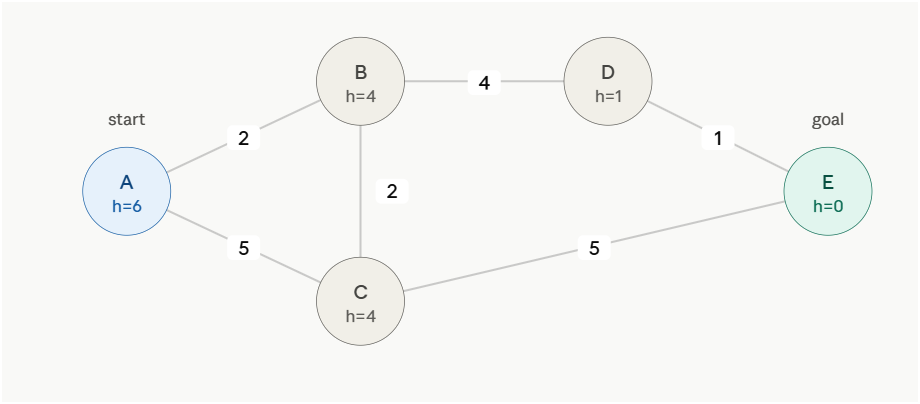


In [ ]:
import heapq
def a_star(graph, heuristics, start, goal):
    pq = []
    heapq.heappush(pq, (heuristics[start], 0, start, [start]))
    visited = set()

    while pq:
        f, g, current, path = heapq.heappop(pq)
        if current == goal:
            return g, path
        if current in visited:
            continue

        visited.add(current)

        for neighbor, move_cost in graph.get(current, ()):
            if neighbor not in visited:
                new_g = g + move_cost
                new_f = new_g + heuristics[neighbor]

                heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return -1, []

graph= {
    'A': (('B', 2), ('C', 5)),
    'B': (('A', 2), ('C', 2), ('D', 4)),
    'C': (('A', 5), ('B', 2), ('E', 5)),
    'D': (('B', 4), ('E', 1)),
    'E': (('C', 5), ('D', 1))
}
heuristics = {'A': 6, 'B': 4, 'C': 4, 'D': 1, 'E': 0}

cost, optimal_path = a_star(graph, heuristics, 'A', 'E')
print(f"Total Path Cost: {cost}")
print(f"Optimal Path: {' -> '.join(optimal_path)}")

Total Path Cost: 7
Optimal Path: A -> B -> D -> E


**Task: (GBFS)**

You are given an undirected, weighted graph consisting of 5 nodes (A, B, C, D, E). You need to write a program that uses the GBFS  to find the shortest path from the starting node **A** to the goal node **E**.

**Given Data:**

  **Start Node:** A

  **Goal Node:** E


**Output Requirement:**
Your program should output the total minimum cost to reach the goal and the sequence of nodes visited to achieve that path.


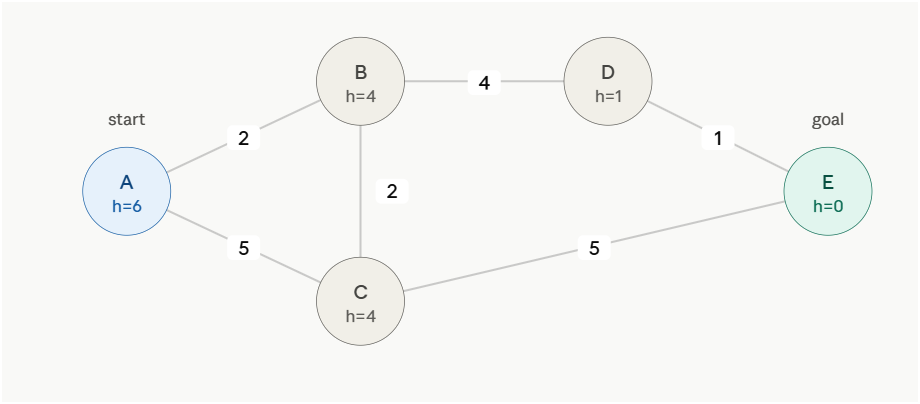


In [ ]:
import heapq

def gbfs(graph, heuristics, start, goal):
    pq = []
    heapq.heappush(pq, (heuristics[start], 0, start, [start]))
    visited = set()
    while pq:
        h, g, current, path = heapq.heappop(pq)
        if current == goal:
            return g, path
        if current in visited:
            continue

        visited.add(current)

        for neighbor, move_cost in graph.get(current, ()):
            if neighbor not in visited:
                new_g = g + move_cost
                new_h = heuristics[neighbor]

                heapq.heappush(pq, (new_h, new_g, neighbor, path + [neighbor]))

    return -1, []

graph = {
    'A': (('B', 2), ('C', 5)),
    'B': (('A', 2), ('C', 2), ('D', 4)),
    'C': (('A', 5), ('B', 2), ('E', 5)),
    'D': (('B', 4), ('E', 1)),
    'E': (('C', 5), ('D', 1))
}
heuristics = {'A': 6, 'B': 4, 'C': 4, 'D': 1, 'E': 0}

cost, optimal_path = gbfs(graph, heuristics, 'A', 'E')
print(f"Total Path Cost: {cost}")
print(f"Optimal Path: {' -> '.join(optimal_path)}")

Total Path Cost: 7
Optimal Path: A -> B -> D -> E


**Task:**

Write a program to check whether heuristic values are admissible or not.

**Admissibility checker:** You need to write a function that takes a graph and a set of heuristic
values as input and outputs whether the heuristic values are admissible or not.

Graph: The graph is an undirected and unweighted graph with N vertices numbered from 1
to N.

Output: Print 1 if all the heuristic values are admissible. Otherwise print 0 and mention which
nodes are not admissible.

Sample Graph:

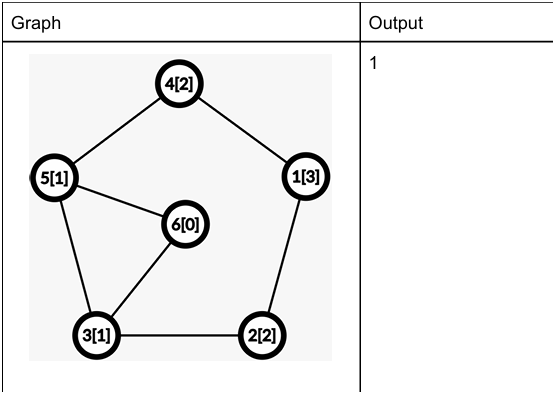

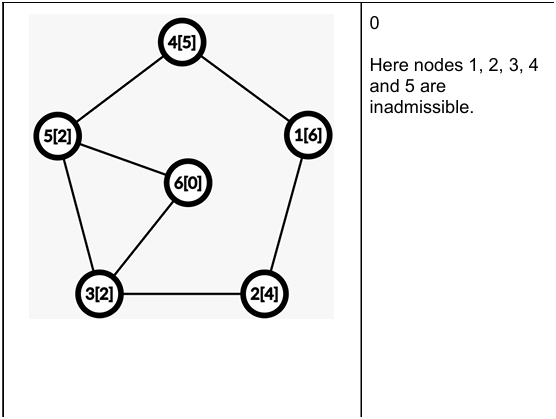

In [ ]:
import heapq

def check_admissibility(graph, heuristics, goal):
    true_costs = {node: float('inf') for node in graph}
    true_costs[goal] = 0
    pq= []
    heapq.heappush(pq,(0,goal))

    while pq:
        current_cost, current = heapq.heappop(pq)
        for neighbor in graph[current]:
            new_cost = current_cost + 1
            if new_cost < true_costs[neighbor]:
                true_costs[neighbor] = new_cost
                heapq.heappush(pq, (new_cost, neighbor))

    inadmissible = []
    for node, h_val in heuristics.items():
        if h_val > true_costs[node]:
            inadmissible.append(node)

    if not inadmissible:
        print(1)
    else:
        print("0")
        inadmissible.sort()
        print("Inadmissible nodes are: ")
        print(inadmissible)


graph_input = {
    1: (2, 4),
    2: (1, 3),
    3: (2, 5, 6),
    4: (1, 5),
    5: (3, 4, 6),
    6: (3, 5)
}

heuristics_input = {
    1: 3,
    2: 2,
    3: 1,
    4: 2,
    5: 1,
    6: 0
}

goal_node = 6

check_admissibility(graph_input, heuristics_input, goal_node)

1




**Task:**

You are given an undirected, weighted graph consisting of 5 nodes (A, B, C, D, E) and a set of heuristic values $h(n)$ representing the estimated cost to reach the goal node **E**. Your task is to determine mathematically and programmatically whether the given heuristics are:

 **Consistent:** The heuristic satisfies the triangle inequality (monotone restriction) for every edge. ($h(n) \le c(n, n') + h(n')$)





---

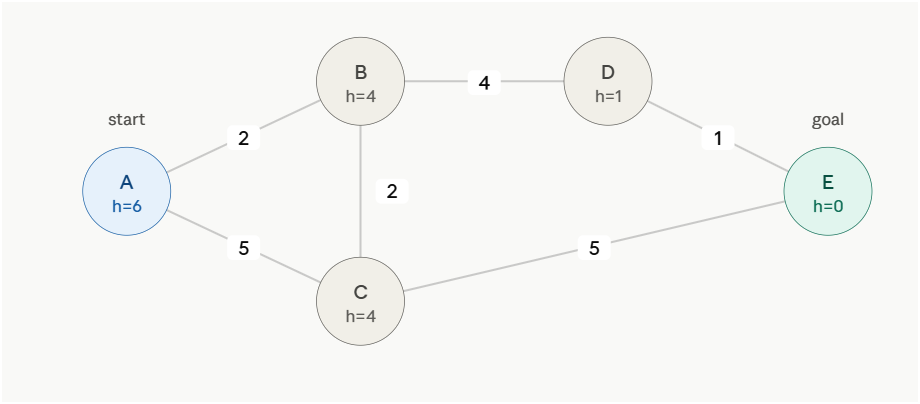


In [ ]:
import heapq

def check_consistency(graph, heuristics):
    inconsistent_edges = []
    for node in graph:
        for neighbor, move_cost in graph[node]:
            if heuristics[node] > move_cost + heuristics[neighbor]:
                inconsistent_edges.append((node, neighbor))

    if not inconsistent_edges:
        print("Consistency: TRUE")
    else:
        print(f"Consistency: FALSE (Inconsistent edges: {inconsistent_edges})")


graph = {
    'A': (('B', 2), ('C', 5)),
    'B': (('A', 2), ('C', 2), ('D', 4)),
    'C': (('A', 5), ('B', 2), ('E', 5)),
    'D': (('B', 4), ('E', 1)),
    'E': (('C', 5), ('D', 1))
}

heuristics = {'A': 6, 'B': 4, 'C': 4, 'D': 1, 'E': 0}
check_consistency(graph, heuristics)

Consistency: TRUE


**Task:**






You are given an undirected, weighted graph representing a simplified road map of part of Romania. You are also provided with a set of heuristic values, $h(n)$, which represent the estimated cost (straight-line distance) to reach the goal node from each specific city.

**Given Data:**

* **Start Node:** Arad
* **Goal Node:** Bucharest
* **Edge Costs:** Represented by the road distances in miles between adjacent cities as shown below.
* **Heuristic Values $h(n)$:** Represented by the straight-line distances to Bucharest as shown below (e.g., Arad = 366, Bucharest = 0, Craiova = 160, etc.).

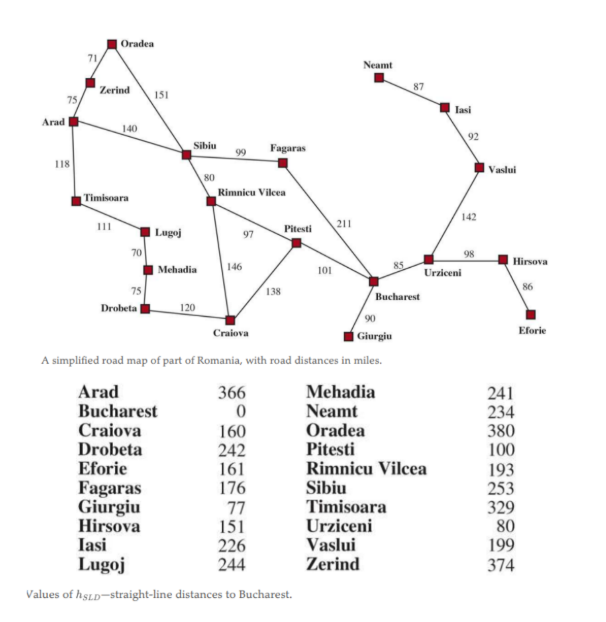

**Tasks:**
Write a program that performs the following three distinct tasks:

1. **$A^*$ Search Implementation:** Utilize the $A^*$ search algorithm to find the optimal (shortest) path from the start node (Arad) to the goal node (Bucharest). Output the total path cost and the sequence of nodes visited.
2. **Admissibility Check:** Determine if the given heuristic is admissible. A heuristic is admissible if $h(n) \le h^*(n)$ for all nodes, where $h^*(n)$ is the true minimum cost from node $n$ to the goal. Output whether it is admissible, and if not, list the nodes that fail the condition.
3. **Consistency Check:** Determine if the given heuristic is consistent. A heuristic is consistent if it satisfies the triangle inequality $h(n) \le c(n,n') + h(n')$ for every edge connecting node $n$ to node $n'$. Output whether it is consistent, and if not, list the edges that fail the condition.

In [ ]:
import heapq

def a_star(graph, heuristics, start, goal):
    pq = []
    heapq.heappush(pq, (heuristics[start], 0, start, [start]))
    visited = set()

    while pq:
        f, g, current, path = heapq.heappop(pq)

        if current == goal:
            return g, path

        if current in visited:
            continue
        visited.add(current)

        for neighbor, move_cost in graph.get(current, ()):
            if neighbor not in visited:
                new_g = g + move_cost
                new_f = new_g + heuristics[neighbor]
                heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return -1, []

def check_admissibility(graph, heuristics, goal):
    true_costs = {node: float('inf') for node in graph}
    true_costs[goal] = 0
    pq= []
    heapq.heappush(pq,(0,goal))
    while pq:
        current_cost, current = heapq.heappop(pq)
        for neighbor, move_cost in graph.get(current, ()):
            new_cost = current_cost + move_cost
            if new_cost < true_costs[neighbor]:
                true_costs[neighbor] = new_cost
                heapq.heappush(pq, (new_cost, neighbor))

    inadmissible = [node for node, h_val in heuristics.items() if h_val > true_costs[node]]

    if not inadmissible:
        print("Admissibility: TRUE ")
    else:
        print(f"Admissibility: FALSE (Failing nodes: {inadmissible})")

def check_consistency(graph, heuristics):
    inconsistent_edges = []
    for node in graph:
        for neighbor, move_cost in graph[node]:
            if heuristics[node] > move_cost + heuristics[neighbor]:
                inconsistent_edges.append((node, neighbor))

    if not inconsistent_edges:
        print("Consistency: TRUE")
    else:
        print(f"Consistency: FALSE (Failing edges: {inconsistent_edges})")


graph = {
    'Arad': (('Zerind', 75), ('Sibiu', 140), ('Timisoara', 118)),
    'Bucharest': (('Fagaras', 211), ('Pitesti', 101), ('Giurgiu', 90), ('Urziceni', 85)),
    'Craiova': (('Drobeta', 120), ('Rimnicu Vilcea', 146), ('Pitesti', 138)),
    'Drobeta': (('Mehadia', 75), ('Craiova', 120)),
    'Eforie': (('Hirsova', 86),),
    'Fagaras': (('Sibiu', 99), ('Bucharest', 211)),
    'Giurgiu': (('Bucharest', 90),),
    'Hirsova': (('Urziceni', 98), ('Eforie', 86)),
    'Iasi': (('Vaslui', 92), ('Neamt', 87)),
    'Lugoj': (('Timisoara', 111), ('Mehadia', 70)),
    'Mehadia': (('Lugoj', 70), ('Drobeta', 75)),
    'Neamt': (('Iasi', 87),),
    'Oradea': (('Zerind', 71), ('Sibiu', 151)),
    'Pitesti': (('Rimnicu Vilcea', 97), ('Craiova', 138), ('Bucharest', 101)),
    'Rimnicu Vilcea': (('Sibiu', 80), ('Craiova', 146), ('Pitesti', 97)),
    'Sibiu': (('Arad', 140), ('Oradea', 151), ('Fagaras', 99), ('Rimnicu Vilcea', 80)),
    'Timisoara': (('Arad', 118), ('Lugoj', 111)),
    'Urziceni': (('Bucharest', 85), ('Vaslui', 142), ('Hirsova', 98)),
    'Vaslui': (('Urziceni', 142), ('Iasi', 92)),
    'Zerind': (('Arad', 75), ('Oradea', 71))
}
heuristics = {
    'Arad': 366,
    'Bucharest': 0,
    'Craiova': 160,
    'Drobeta': 242,
    'Eforie': 161,
    'Fagaras': 176,
    'Giurgiu': 77,
    'Hirsova': 151,
    'Iasi': 226,
    'Lugoj': 244,
    'Mehadia': 241,
    'Neamt': 234,
    'Oradea': 380,
    'Pitesti': 100,
    'Rimnicu Vilcea': 193,
    'Sibiu': 253,
    'Timisoara': 329,
    'Urziceni': 80,
    'Vaslui': 199,
    'Zerind': 374
}

start_node = 'Arad'
goal_node = 'Bucharest'

print("--- Running A* Search ---")
cost, path = a_star(graph, heuristics, start_node, goal_node)
if cost != -1:
    print(f"Total Path Cost: {cost}")
    print(f"Optimal Path: {' -> '.join(path)}")
else:
    print("No path found.")

print("\n--- Running Heuristic Checks ---")
check_admissibility(graph, heuristics, goal_node)
check_consistency(graph, heuristics)

--- Running A* Search ---
Total Path Cost: 418
Optimal Path: Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest

--- Running Heuristic Checks ---
Admissibility: TRUE 
Consistency: TRUE


<div style="pointer-events: none; user-select: none;">
  <p><strong>Task:</strong></p>

  <p>You are to write the program of a Maze Solver Agent to find a path through a maze from an entry point to an exit point using the A* search algorithm.</p>

  <p><strong>Maze:</strong> For this task, the maze is of size N x M, where N is the height and M is the width of the maze. The maze is described using 2 symbols, "0" and "#", where "0"s denote the paths and "#"s denote the walls. In addition, the mazes will have only one entry point and only one exit point.</p>

  <p><strong>Heuristic function:</strong> You need to use the Manhattan distance as the heuristic function. For two points (𝑥₁, 𝑦₁) and (𝑥₂, 𝑦₂), the Manhattan distance is calculated as:</p>

  <p>|𝑥₁ − 𝑥₂| + |𝑦₁ − 𝑦₂|</p>

  <p><strong>Moves:</strong> The agent can move only in horizontal and vertical directions. It cannot move in diagonal directions.</p>

  <p><strong>Cost:</strong> The cost of each move in the maze is 1.</p>

  <p><strong>Output:</strong><br>
  The first output will be the total path cost (number of steps required to exit the maze).<br>
  The second output will be the sequence of actions to go from initial to goal state.</p>

  <p>[It will contain a sequence of actions represented using the characters U (Up), D (Down), R (Right), and L (Left). Print -1 if no path is found].</p>
</div>

**Example Maze:**
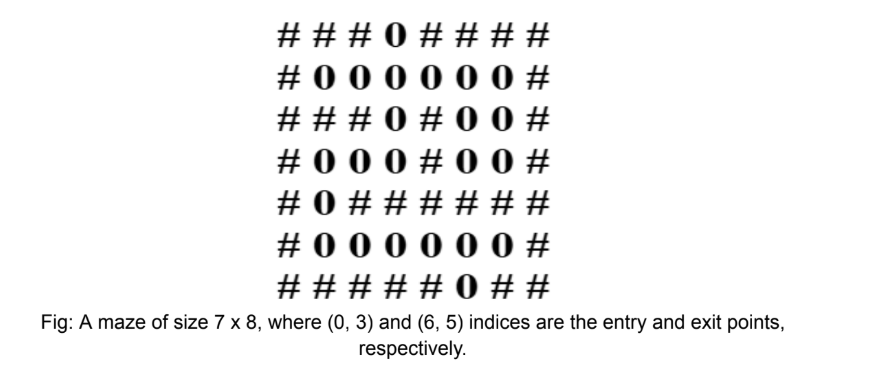

In [ ]:
import heapq
def manhattan_distance(p1,p2):
  # Calculates |x1 - x2| + |y1 - y2|
  return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

def maze_solve(maze, start,goal):
  rows = len(maze)
  cols = len(maze[0])
  directions = [(-1,0,'U'),(1,0,'D'),(0,-1,'L'),(0,1,'R')]
  pq =[]
  # Priority queue stores tuples of: (f_score, g_score, current_node, path_string)
  heapq.heappush(pq, (manhattan_distance(start,goal),0,start,""))
  visited = set()

  while pq:
    f,g,current,path = heapq.heappop(pq)

    if current==goal:
      return g,path

    if current in visited:
      continue

    visited.add(current)

    for x,y, action in directions:
      new_x, new_y = current[0]+x, current[1]+y

      if 0<=new_x <rows and 0<=new_y<cols and maze[new_x][new_y]=='0':
        if(new_x,new_y) not in visited:
          new_g = g+1;
          new_f = new_g + manhattan_distance((new_x,new_y),goal)
          heapq.heappush(pq,(new_f,new_g,(new_x,new_y),path+action))


  return -1,""


maze = [
    "###0####",
    "#000000#",
    "###0#00#",
    "#000#00#",
    "#0######",
    "#000000#",
    "#####0##"
]

start_node  = (0,3)
goal_node = (6,5)
cost, path = maze_solve(maze, start_node, goal_node)
if cost != -1:
  print(cost)
  print(path)
else:
  print("-1")



12
DDDLLDDRRRRD
